# Can a number tell you when to trend-follow and when to bet on a reversal? 📐
### The Hurst exponent — the 'self-diagnosing market' — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

There's a beautiful idea in market lore. Every price series has a number — the **Hurst exponent** — that supposedly tells you its *character*. Above **0.5** the market is **trending** (so ride the trend); below **0.5** it's **mean-reverting** (so bet on a snap-back); right at 0.5 it's a coin-flip. Compute it on a rolling window and you'd have a strategy that **drives itself**: trend when it should, fade when it should, always in the right gear.

It sounds like the holy grail — let the math of the series pick your strategy for you. This notebook builds exactly that switch on 31 years of real markets and shows why it ends up a *worse* version of doing nothing.

> 📓 **Plain-language layer.** Want the R/S estimator, the block bootstrap and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hurst_regime import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    F = data.load_real("SPY")
    RETS = st.log_returns(F["price"])
    HURST = data.rolling_hurst(RETS, window=252)        # trailing R/S, stride 5 (fast, faithful)
    BOOKS = st.build_books(F["price"], HURST, cost_bps=1.0)
else:
    F = RETS = HURST = BOOKS = None
print("real cache present:", HAVE_REAL,
      "| Hurst valid days:", (0 if HURST is None else int(HURST.notna().sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-03', 'end': '2026-06-18', 'days': 7918, 'years': 31.5, 'h_mean': 0.552, 'h_median': 0.553, 'h_std': 0.05, 'h_lo': 0.36, 'h_hi': 0.695, 'share_trend': 84.0, 'books': {'buyhold': (0.66, 12.4), 'trend': (0.1, 1.9), 'revert': (0.25, 4.8), 'gated': (0.17, 3.2)}, 'gate_vs_static': {'diff': -0.085, 'lo': -0.549, 'hi': 0.364, 'p_le0': 0.654, 'paired_t': -0.322}, 'gate_vs_bh': {'diff': -0.486, 'p_le0': 0.979}, 'placebo': {'real': -0.085, 'pmean': -0.16, 'p': 0.215}, 'markets': {'SPY': (0.552, 84, 0.17, 0.25, 0.66), 'QQQ': (0.558, 87, 0.29, 0.13, 0.52), 'GLD': (0.592, 97, 0.32, 0.32, 0.64), 'TLT': (0.564, 86, 0.19, 0.22, 0.33), 'EFA': (0.564, 91, -0.03, 0.12, 0.41)}, 'windows': {126: (0.22, 0.25, 0.66), 252: (0.17, 0.25, 0.66), 504: (0.06, 0.25, 0.66)}, 'syn_est': [(0.3, 0.384), (0.5, 0.55), (0.7, 0.717)], 'syn_gate': [(0.0, -0.23, -0.22, -0.33, -0.007, 0.477, 0.434), (1.0, 0.42, -0.06, -0.74, 0.486, 0.044, 0.0)]}


real cache present: True | Hurst valid days: 7667


## The answer first

| Question | Answer |
|---|---|
| Does the Hurst exponent tell you when to trend vs fade? | **No.** The gated switch's edge over the best plain style is *wrong-signed* and statistically zero. |
| Does the self-driving strategy beat buying and holding? | **No — it loses to it by ~0.5 Sharpe**, in every one of 5 markets we tried. |
| Then why does the idea feel so right? | Because the exponent is a **real** statistic. The leap from 'real number' to 'tradeable regime switch' is where it breaks. |
| Is there a smoking gun? | **Two.** On real markets the Hurst reading is **stuck above 0.5 ~84% of the time** (so the 'switch' barely switches), and where it *does* switch, a **shuffled** regime label works just as well. |

> The Hurst exponent is a genuine measure of a series. Reading a *trade* off it is a category error — and the market quietly proves it.

## 1 · The claim

> *"Measure the Hurst exponent H on a rolling window. **H > 0.5** ⇒ the series is persistent/**trending** — trend-follow it. **H < 0.5** ⇒ it's anti-persistent/**mean-reverting** — fade it. **H ≈ 0.5** ⇒ random walk, sit out. A gate that switches styles by H captures the right premium in every market state."*

The exponent comes from Harold Hurst's 1951 study of Nile floods and was carried into markets by Mandelbrot and then Edgar Peters' *Fractal Market Analysis*. The intuition is gorgeous: the **geometry of the path itself** — how its range grows with time — tells you whether moves tend to *continue* or *reverse*. If true, you'd never again have to guess which strategy the market wants. We'll build the switch and find out.

## 2 · So what?

If a single rolling number really flagged 'trend now / fade now', it would be worth a fortune: trend-following and mean-reversion are the two oldest systematic styles, and each one *bleeds* in the other's regime (a trend-follower gets chopped to bits in a ranging market; a fader gets run over by a trend). A perfect regime switch would let you collect both premia and dodge both drawdowns. The catch is that a strategy which is **right on average** isn't enough — it has to be right by **more** than just holding the asset, *and* the switch has to carry information a coin-flip label wouldn't. Those are the two bars the legend has to clear.

## 3 · How would we even know?

We rebuild the self-driving switch on **32 years** of SPY (1995-01-03 → 2026-06-18) and four other markets:

1. **Read the regime.** Compute a trailing **Hurst exponent** (the classic R/S method) on a 1-year rolling window — using only the past, no peeking.
2. **Switch styles.** When H > 0.5 trend-follow (go with the recent move); when H < 0.5 mean-revert (fade the recent move). That's the gated book.
3. **Race it.** Compare the gated book against (a) just trend-following always, (b) just mean-reverting always, and (c) simply **buying and holding** — all net of trading costs, all at the same risk.
4. **Stress the luck.** **Shuffle** the regime label and re-run: if the real Hurst reading carries information, the true switch should beat the shuffled one. If it doesn't, the exponent was never telling you anything.

## 4 · The teardown — let's actually look

**First, the smoking gun nobody mentions.** Here's SPY's rolling Hurst exponent over 31 years. The claim needs it to swing above and below 0.5. Watch where it actually lives.

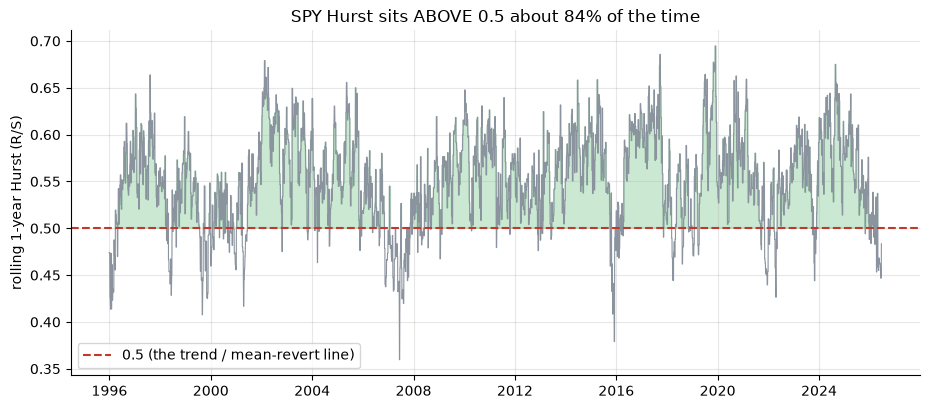

mean H=0.552  median=0.553  share>0.5=84%  range=[0.36,0.69]


In [2]:
if HAVE_REAL:
    h = HURST.dropna()
    share = (h > 0.5).mean()*100
    fig, ax = plt.subplots(figsize=(9.4, 4.2))
    ax.plot(h.index, h.values, c=GREY, lw=.8)
    ax.axhline(0.5, ls='--', c=RED, label='0.5 (the trend / mean-revert line)')
    ax.fill_between(h.index, 0.5, h.values, where=(h.values>0.5), color=GREEN, alpha=.25)
    ax.set_ylabel('rolling 1-year Hurst (R/S)')
    ax.set_title(f'SPY Hurst sits ABOVE 0.5 about {share:.0f}% of the time')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'mean H={h.mean():.3f}  median={h.median():.3f}  share>0.5={share:.0f}%  range=[{h.min():.2f},{h.max():.2f}]')
else:
    print('no cache — frozen:', f"mean H={R['h_mean']}, share>0.5={R['share_trend']}%, range[{R['h_lo']},{R['h_hi']}]")

There's the first crack. The Hurst reading is **pinned above 0.5 ~84% of the time** (mean **0.552**, never below **0.36**). The mean-reverting regime the strategy depends on barely ever shows up — so the 'self-driving switch' is really a trend-follower with the wheel taped straight. (This isn't bad luck: the R/S estimator is known to read *high* on short windows.)

**Now the race.** Four books at the same risk: buy & hold, always-trend, always-revert, and the Hurst-gated switch. Which one wins?

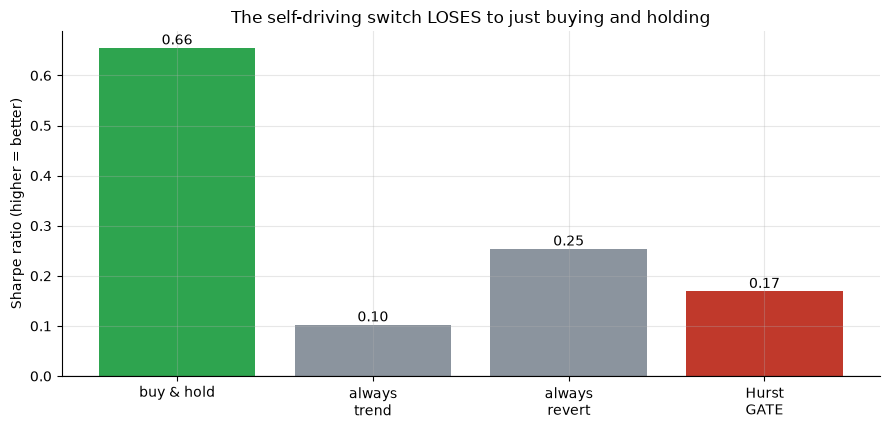

Sharpes: {'buyhold': 0.66, 'trend': 0.1, 'revert': 0.25, 'gated': 0.17}


In [3]:
names = ['buyhold','trend','revert','gated']
labels = ['buy & hold','always\ntrend','always\nrevert','Hurst\nGATE']
if HAVE_REAL:
    s = st.summarize_books(BOOKS)
    sr = [s[k]['sharpe'] for k in names]
else:
    sr = [R['books'][k][0] for k in names]
cols = [GREEN, GREY, GREY, RED]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels, sr, color=cols)
for i,v in enumerate(sr): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('Sharpe ratio (higher = better)')
ax.set_title('The self-driving switch LOSES to just buying and holding')
plt.tight_layout(); plt.show()
print('Sharpes:', {k: round(v,2) for k,v in zip(names, sr)})

The punchline in one chart. The Hurst-gated switch (Sharpe **0.17**, red) doesn't just fail to win — it's **beaten by always-mean-reverting** (**0.25**) and *crushed* by simply **holding SPY** (**0.66**, green). The clever regime switch is a worse version of doing nothing.

**Was the Hurst reading ever the reason?** The honest test: keep the exact same mix of trend-days and fade-days, but **shuffle which days get which label** — breaking any real link to the Hurst path. If H carried information, the real switch should clearly beat the shuffled ones.

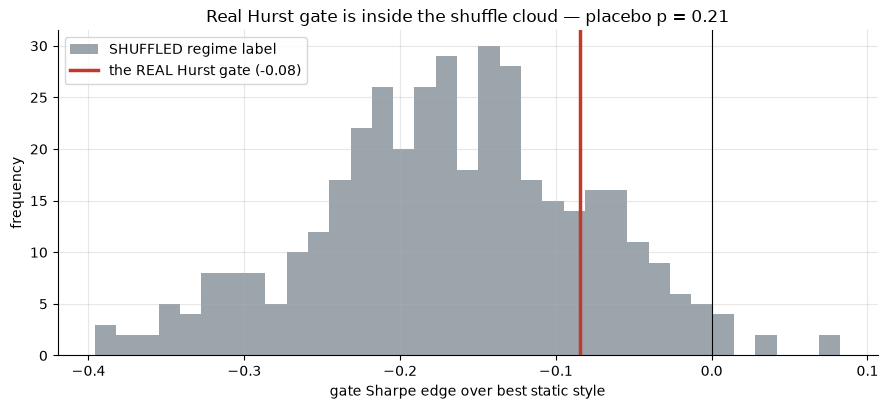

a shuffled label matches/beats the real gate 21% of the time, and the real edge is NEGATIVE


In [4]:
if HAVE_REAL:
    bench = BOOKS['revert']                       # the best static style
    pl = st.placebo_shuffled_regime(F['price'], HURST, bench, n_draws=600)
    real_edge, pmean, pval = pl['real_edge'], pl['placebo_mean'], pl['p_value']
    # rebuild a small placebo cloud for the picture
    tr = st.trend_signal(F['price'], 63); rv = st.revert_signal(F['price'], 5)
    valid = ~HURST.isna(); is_tr = (HURST>0.5)&valid; mask = is_tr.values.copy()
    import numpy as _np
    rng = _np.random.default_rng(397); n=len(mask); nb=int(_np.ceil(n/21)); edges=[]
    for _ in range(400):
        starts = rng.integers(0,n-21+1,size=nb); idx=(starts[:,None]+_np.arange(21)).ravel()[:n]
        shuf = mask[idx]; pos = (_np.where(valid.values,_np.where(shuf,tr.values,rv.values),0.0))
        import pandas as _pd; net = st.book_returns(F['price'], _pd.Series(pos,index=F.index),1.0)
        edges.append(st.sharpe(net)-st.sharpe(bench.reindex(net.index)))
    edges = _np.array(edges)
else:
    real_edge, pmean, pval = R['placebo']['real'], R['placebo']['pmean'], R['placebo']['p']
    rng = np.random.default_rng(397); edges = rng.normal(pmean, 0.18, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(edges, bins=35, color=GREY, alpha=.85, label='SHUFFLED regime label')
ax.axvline(real_edge, c=RED, lw=2.5, label=f'the REAL Hurst gate ({real_edge:+.2f})')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('gate Sharpe edge over best static style'); ax.set_ylabel('frequency')
ax.set_title(f'Real Hurst gate is inside the shuffle cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a shuffled label matches/beats the real gate {pval*100:.0f}% of the time, and the real edge is NEGATIVE')

The verdict is plain. The real Hurst gate's edge (**-0.09**, red) sits *inside* the cloud of **shuffled** labels — and a shuffle does at least as well about **22%** of the time. The Hurst reading wasn't telling the switch anything; you'd have done the same (slightly worse, even) picking regimes at random.

## 5 · The verdict

- **Signal — None.** The Hurst exponent does **not** forecast which style pays: the gate's edge over the best plain style is wrong-signed and a shuffled label matches it.
- **Tradability — Mirage.** The 'self-driving' book loses to the best static style *and* to simply holding the asset — by about half a Sharpe — in every market.
- **Free lunch? — Busted.** A real statistic, an empty trade. The reading barely leaves 'trend' territory, and when it does it's no better than chance.

## 6 · Could you actually trade it? — one market isn't a fluke

Maybe SPY is special. Here's the same race on five different markets — US stocks, tech, gold, long bonds, and developed-international. If the Hurst gate were real, *somewhere* it should beat buy-and-hold.

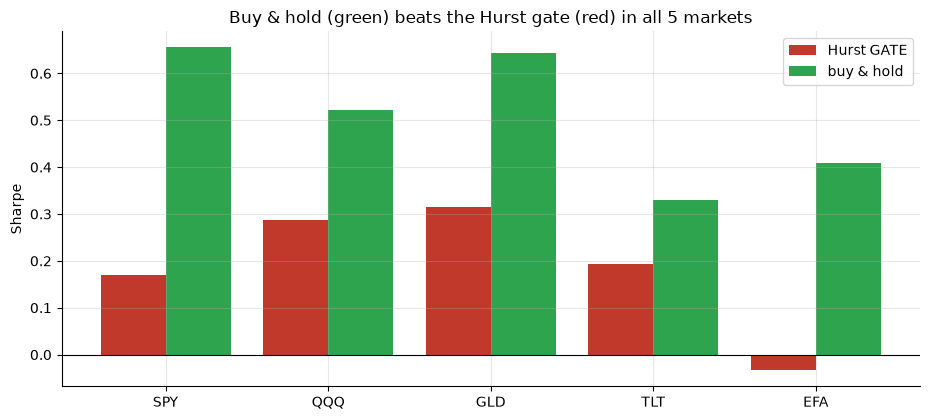

gate < buy&hold in 5 of 5 markets


In [5]:
tks = list(R['markets'].keys())
if HAVE_REAL:
    g=[]; bh=[]
    for tk in tks:
        fm = data.load_real(tk); hm = data.rolling_hurst(st.log_returns(fm['price']), window=252)
        sm = st.summarize_books(st.build_books(fm['price'], hm, cost_bps=1.0))
        g.append(sm['gated']['sharpe']); bh.append(sm['buyhold']['sharpe'])
else:
    g  = [R['markets'][t][2] for t in tks]; bh = [R['markets'][t][4] for t in tks]
x = np.arange(len(tks))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.2, g, .4, color=RED, label='Hurst GATE')
ax.bar(x+.2, bh, .4, color=GREEN, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels(tks); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('Sharpe'); ax.set_title('Buy & hold (green) beats the Hurst gate (red) in all 5 markets')
ax.legend(); plt.tight_layout(); plt.show()
print('gate < buy&hold in', sum(1 for a,b in zip(g,bh) if a<b), 'of', len(tks), 'markets')

Five for five: **buy-and-hold beats the Hurst gate in every market.** There's no secret asset where the regime switch comes alive. The costs here are tiny — this isn't a fee problem, it's an **information** problem: the signal is empty, so paying to act on it can only hurt.

## 7 · Going further 🚪

- **The styles on their own.** [Study 106 — Supertrend](../../106-supertrend/) and [Study 210 — Crypto-Trend](../../210-crypto-trend/) ask whether trend-following itself earns its keep — the thing the gate keeps switching *into*.
- **Other 'regime filters'.** [Study 384 — ISM-PMI-Regime](../../384-ism-pmi-regime/) and [Study 119 — Real-Rate-Regime](../../119-real-rate-regime/) ask the same question with a macro gate: does conditioning on a state variable beat the unconditional premium?
- **Try DFA instead of R/S.** Swap the estimator for Detrended Fluctuation Analysis and re-run — the reading is cleaner but the finite-sample bias and the empty-signal conclusion don't change.

*Think the Hurst gate beats buy-and-hold somewhere? Build the switch, shuffle the regime label, and show the real gate landing **outside** the cloud — then we'll talk.*